Name: **Robb Ryan P. Calvez**  
Year & Section: **BS CpE 3A**


**Moons Classification Assessment**

---

### **Import Libraries**

In [26]:
import tensorflow as tf
import pandas as pd
import numpy as np
import sklearn
import matplotlib as mpl
import matplotlib.pyplot as plt
import itertools

from sklearn.datasets import make_moons
from sklearn.metrics import confusion_matrix


print(f'Tensorflow: {tf.__version__}\n',
      f'Pandas: {pd.__version__}\n',
      f'numpy: {np.__version__}\n',
      f'sklearn: {sklearn.__version__}\n')


Tensorflow: 2.21.0
 Pandas: 3.0.2
 numpy: 2.4.2
 sklearn: 1.8.0



### **Prep Dataset**

In [27]:
n_samples = 1000

X, y = make_moons(n_samples,
                  noise=0.15,
                  random_state=42)

In [28]:
moons = pd.DataFrame({"X0": X[:, 0], 
                      "X1": X[:, 1], 
                      "label":y})

moons.head()

,X0,X1,label
0,-0.081568,0.482211,1
1,1.087333,-0.381159,1
2,0.831725,-0.133135,1
3,0.200339,-0.500300,1
4,-0.824953,0.539526,0


In [29]:
moons.label.value_counts()

label
1    500
0    500
Name: count, dtype: int64

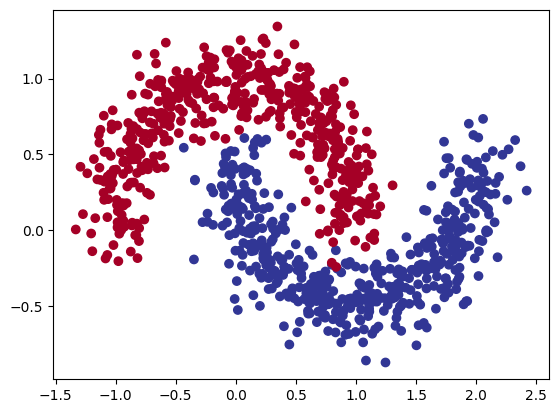

In [30]:
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.RdYlBu)

In [31]:
X_train, y_train = X[:800], y[:800]
X_test, y_test = X[800:], y[800:]

# Normalize the data using min-max scaling (0-1 range)
X_train_normalized = (X_train - X_train.min(axis=0)) / (X_train.max(axis=0) - X_train.min(axis=0))
X_test_normalized = (X_test - X_test.min(axis=0)) / (X_test.max(axis=0) - X_test.min(axis=0))

X_train_normalized.min(), X_train_normalized.max()

(np.float64(-2.186358393765752), np.float64(2.1593119447315767))

### **Find the Ideal Learning Rate**

#### **Ideal Learning Rate for Raw Data**

In [32]:
tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              metrics=['accuracy'])

lr_callback = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-5 * 10**(epoch/20))

history = model.fit(X_train, y_train, 
                    epochs=100,
                    callbacks=[lr_callback])  



Epoch 1/100


I0000 00:00:1781669149.242353   10315 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_36326__.8


25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.2812 - loss: 0.7226 - learning_rate: 1.0000e-05
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2862 - loss: 0.7204 - learning_rate: 1.1220e-05
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2900 - loss: 0.7180 - learning_rate: 1.2589e-05
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2925 - loss: 0.7153 - learning_rate: 1.4125e-05
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2975 - loss: 0.7123 - learning_rate: 1.5849e-05
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3050 - loss: 0.7089 - learning_rate: 1.7783e-05
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3075 - loss: 0.7052 - learning_rate: 1.9953e-05
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3075 - loss: 0.7011 - learning_rate: 2.2387e-05
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3162 - loss: 0.6966 - learning_rate: 2.5119

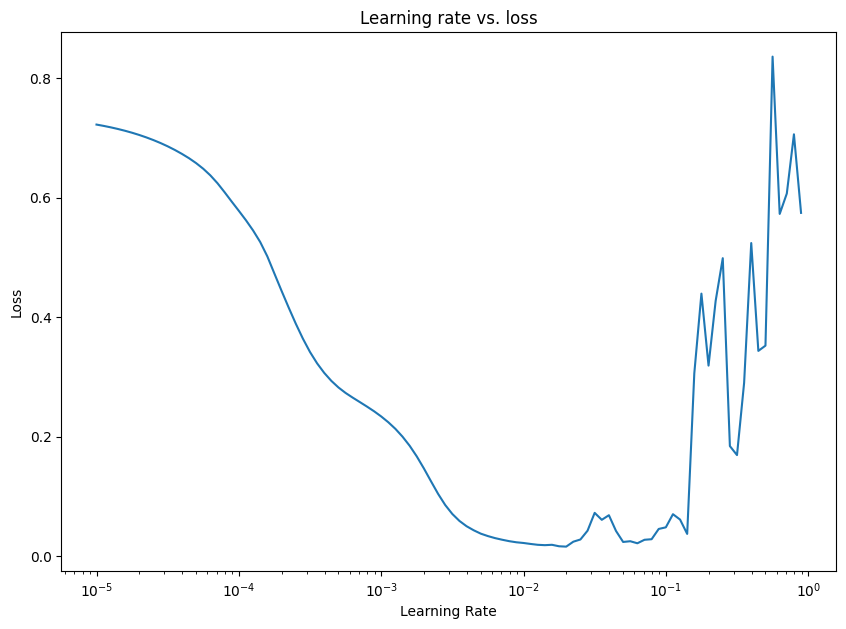

In [33]:
lrs = 1e-5 * (10 ** (np.arange(100)/20))
plt.figure(figsize=(10, 7))
plt.semilogx(lrs, history.history["loss"]) 
plt.xlabel("Learning Rate") 
plt.ylabel("Loss")
plt.title("Learning rate vs. loss");

as per the graph above, somewhere around ```learning_rate = 0.018``` is the safest option.


#### **Ideal Learning Rate for Normalized Data**

Epoch 1/100


I0000 00:00:1781670656.298264   10318 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_99062__.8


25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4988 - loss: 0.7294 - learning_rate: 1.0000e-05
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4988 - loss: 0.7266 - learning_rate: 1.1220e-05
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4988 - loss: 0.7234 - learning_rate: 1.2589e-05
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4988 - loss: 0.7199 - learning_rate: 1.4125e-05
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4988 - loss: 0.7161 - learning_rate: 1.5849e-05
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4988 - loss: 0.7118 - learning_rate: 1.7783e-05
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4988 - loss: 0.7069 - learning_rate: 1.9953e-05
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4988 - loss: 0.7016 - learning_rate: 2.2387e-05
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5000 - loss: 0.6956 - learning_rate: 2.5119

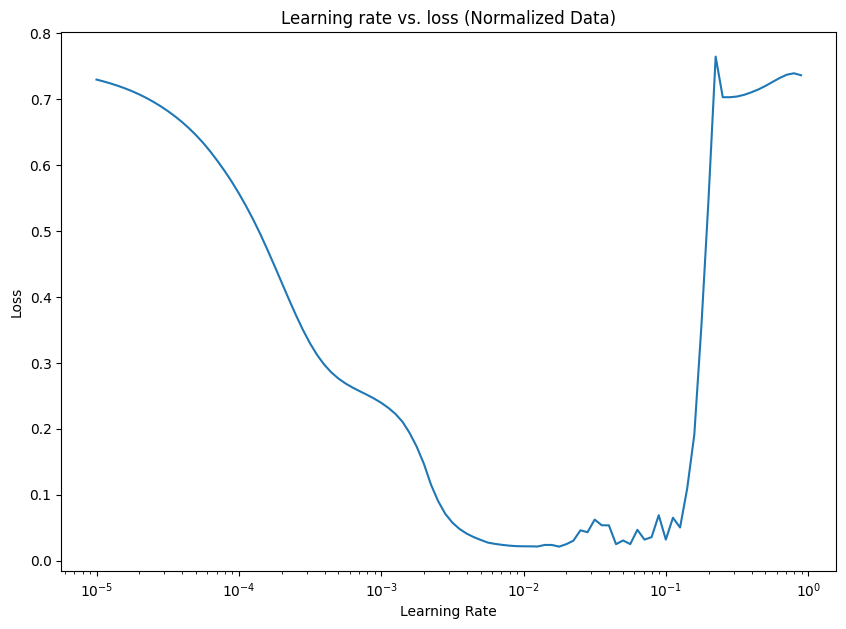

In [53]:
tf.random.set_seed(42)

model_normalized = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_normalized.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              metrics=['accuracy'])

lr_callback = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-5 * 10**(epoch/20))

history_normalized = model_normalized.fit(X_train_normalized, y_train, 
                    epochs=100,
                    callbacks=[lr_callback])  

lrs = 1e-5 * (10 ** (np.arange(100)/20))
plt.figure(figsize=(10, 7))
plt.semilogx(lrs, history_normalized.history["loss"]) 
plt.xlabel("Learning Rate") 
plt.ylabel("Loss")
plt.title("Learning rate vs. loss (Normalized Data)");

as per the graph above, somewhere around ```learning_rate = 0.0045``` is the safest option for normalized data.

### **Create Model with Optimal Learning Rate**

#### **Model Trained on Raw Data**

In [42]:
tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.018), 
              metrics=['accuracy'])

history = model.fit(X_train, y_train, 
                    epochs=20,
                    validation_split=0.2)

Epoch 1/20


I0000 00:00:1781669688.278443   10317 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_80727__.8


20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.8391 - loss: 0.3842 - val_accuracy: 0.9375 - val_loss: 0.1767
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8656 - loss: 0.2813 - val_accuracy: 0.9563 - val_loss: 0.1435
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8938 - loss: 0.2150 - val_accuracy: 0.9750 - val_loss: 0.1152
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9453 - loss: 0.1377 - val_accuracy: 0.9750 - val_loss: 0.0858
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9828 - loss: 0.0693 - val_accuracy: 0.9625 - val_loss: 0.1192
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9828 - loss: 0.0497 - val_accuracy: 0.9688 - val_loss: 0.0901
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9828 - loss: 0.0567 - val_accuracy: 0.9875 - val_loss: 0.0391
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9875 - loss: 0.0458 - val_accuracy: 0.9875 - val_loss: 0.0206
Ep

#### **Model Trained on Normalized Data**

In [54]:
tf.random.set_seed(42)

model_normalized = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_normalized.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.0045),
              metrics=['accuracy'])

history_normalized = model_normalized.fit(X_train_normalized, y_train, 
                    epochs=20,
                    validation_split=0.2)

Epoch 1/20


I0000 00:00:1781670784.871484   10318 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_112210__.8


20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.8406 - loss: 0.4486 - val_accuracy: 0.9500 - val_loss: 0.1851
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8656 - loss: 0.2888 - val_accuracy: 0.9312 - val_loss: 0.1640
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8797 - loss: 0.2544 - val_accuracy: 0.9563 - val_loss: 0.1470
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9047 - loss: 0.2088 - val_accuracy: 0.9625 - val_loss: 0.1241
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9328 - loss: 0.1541 - val_accuracy: 0.9750 - val_loss: 0.0975
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9703 - loss: 0.1031 - val_accuracy: 0.9812 - val_loss: 0.0721
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9812 - loss: 0.0706 - val_accuracy: 0.9812 - val_loss: 0.0546
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9906 - loss: 0.0541 - val_accuracy: 0.9812 - val_loss: 0.0431

### **Display Results**

In [55]:
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    x_input = np.c_[xx.ravel(), yy.ravel()]
    
    y_pred = model.predict(x_input)
    
    if model.output_shape[-1] > 1: 
        print("doing multiclass classification...")
        
        y_pred = np.argmax(y_pred, axis=1).reshape(xx.shape)
    else:
        print('doing binary classification...')
        y_pred = np.round(np.max(y_pred, axis=1)).reshape(xx.shape)
        
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

In [56]:
def plot_confusion_matrix(cm, title):
    figsize = (8, 8)

    cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
    n_classes = cm.shape[0]

    fig, ax = plt.subplots(figsize=figsize)
    cax = ax.matshow(cm, cmap=plt.cm.Blues)
    fig.colorbar(cax)

    labels = np.arange(n_classes)

    ax.set(
        title=title,
        xlabel="Predicted Label",
        ylabel="True Label",
        xticks=np.arange(n_classes),
        yticks=np.arange(n_classes),
        xticklabels=labels,
        yticklabels=labels
    )

    ax.xaxis.set_label_position("bottom")
    ax.xaxis.tick_bottom()

    threshold = (cm.max() + cm.min()) / 2.

    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        ax.text(
            j, i,
            f"{cm[i, j]}\n({cm_norm[i, j]*100:.1f}%)",
            horizontalalignment="center",
            color="white" if cm[i, j] > threshold else "black",
            fontsize=12
        )

    plt.show()

#### **Accuracy / Loss Graph**

Text(0.5, 1.0, 'Normalized Data Model Training')

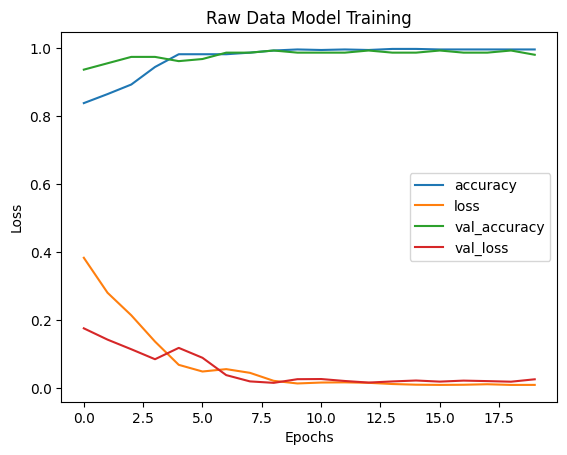

<Figure size 640x480 with 0 Axes>

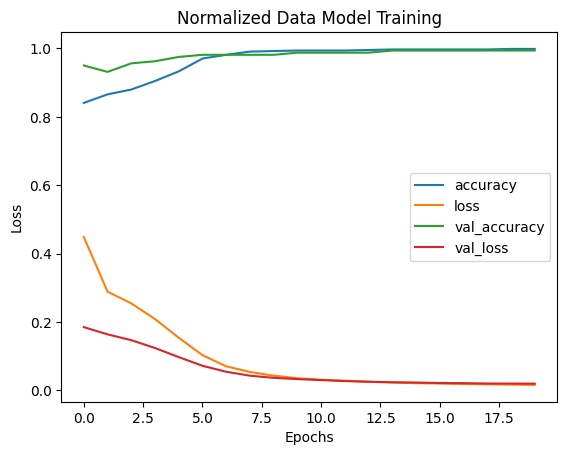

In [57]:
pd.DataFrame(history.history).plot()
mpl.pyplot.xlabel('Epochs')
mpl.pyplot.ylabel('Loss')
mpl.pyplot.title('Raw Data Model Training')
plt.figure()
pd.DataFrame(history_normalized.history).plot()
mpl.pyplot.xlabel('Epochs')
mpl.pyplot.ylabel('Loss')
mpl.pyplot.title('Normalized Data Model Training')

#### **Normalized vs Raw Training Sets**

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
doing binary classification...
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
doing binary classification...
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
doing binary classification...
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
doing binary classification...


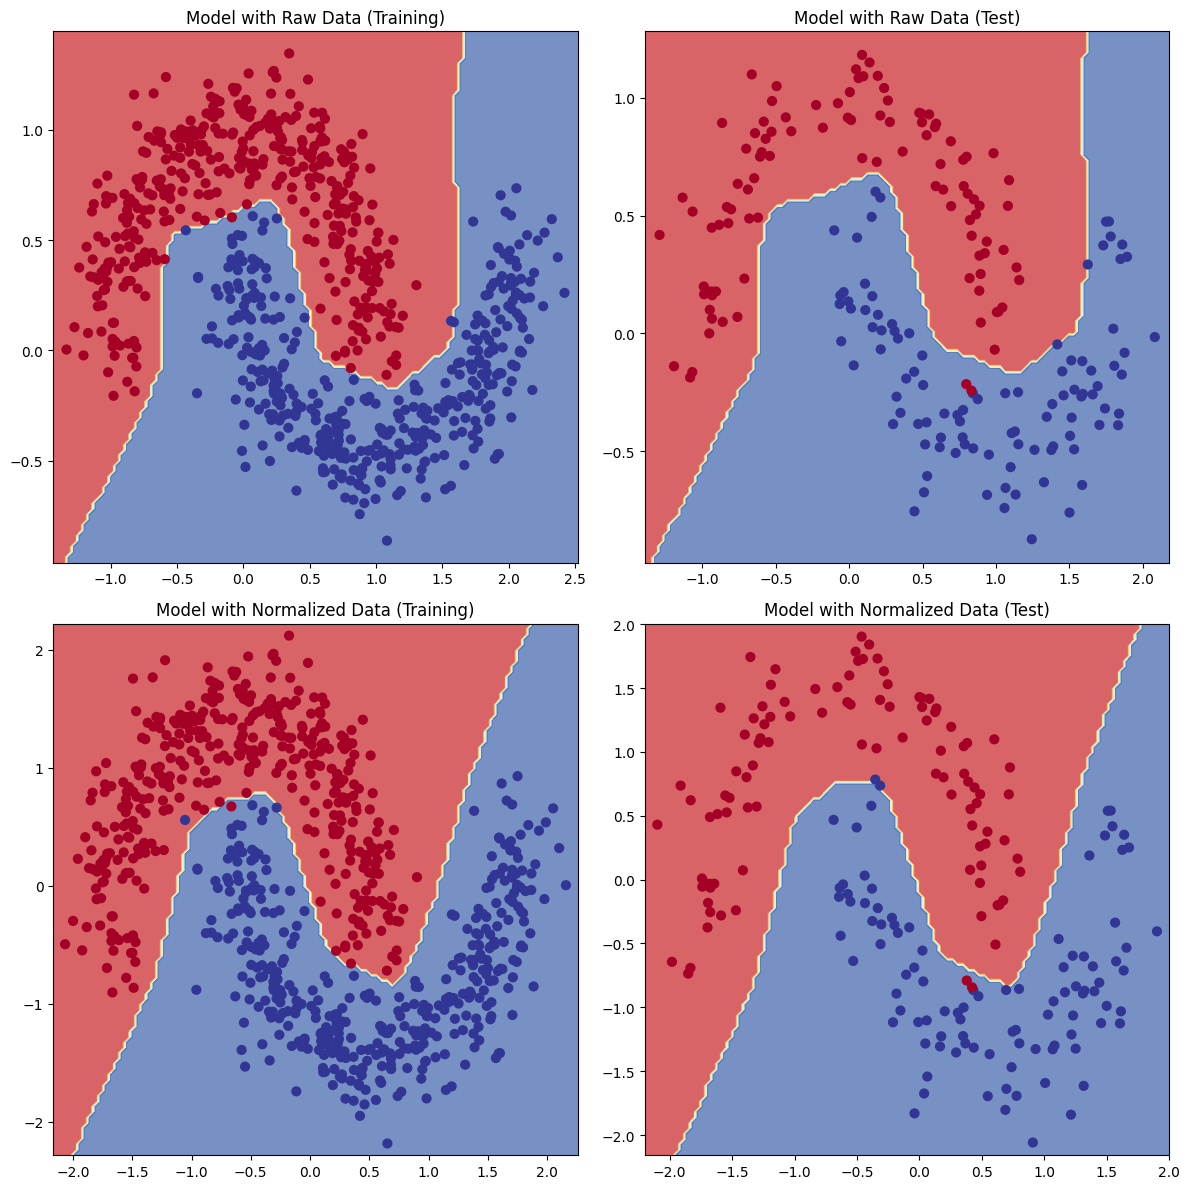

In [58]:
plt.figure(figsize=(12, 12))

plots = [
    ('Model with Raw Data (Training)', model, X_train, y_train),
    ('Model with Raw Data (Test)', model, X_test, y_test),
    ('Model with Normalized Data (Training)', model_normalized, X_train_normalized, y_train),
    ('Model with Normalized Data (Test)', model_normalized, X_test_normalized, y_test)
]

for i, (title, selected_model, img_data, labels) in enumerate(plots):
    plt.subplot(2, 2, i + 1)   # create/select subplot first
    plt.title(title)           # then set title on that subplot

    plot_decision_boundary(
        selected_model,
        img_data,
        labels
    )

plt.tight_layout()

#### **Confusion Matrices Comparison**

In [59]:
# Model w/ Raw data 
y_preds_raw = model.predict(X_test)
cm_raw = confusion_matrix(y_test, tf.round(y_preds_raw))
print("Raw Data Model Confusion Matrix:")
print(cm_raw)

# Model w/ Normalized data 
y_preds_normalized = model_normalized.predict(X_test_normalized)
cm_normalized = confusion_matrix(y_test, tf.round(y_preds_normalized))
print("\nNormalized Data Model Confusion Matrix:")
print(cm_normalized)

1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Raw Data Model Confusion Matrix:
[[99  2]
 [ 1 98]]
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

Normalized Data Model Confusion Matrix:
[[99  2]
 [ 2 97]]


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Raw Data Model Confusion Matrix:
[[99  2]
 [ 1 98]]


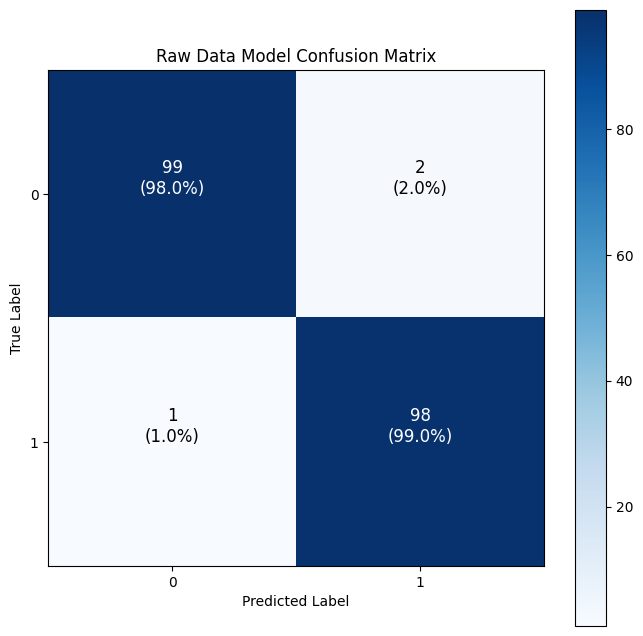

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

Normalized Data Model Confusion Matrix:
[[99  2]
 [ 2 97]]


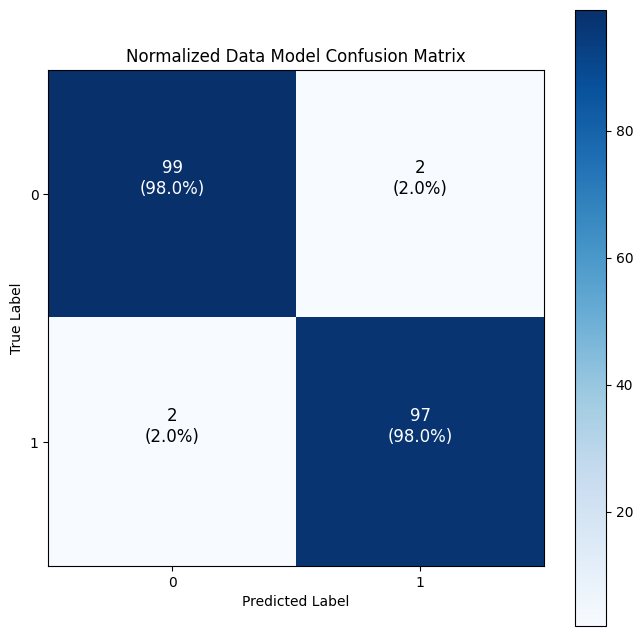

In [60]:
# Raw Data Model
y_preds_raw = model.predict(X_test)
cm_raw = confusion_matrix(y_test, tf.round(y_preds_raw))

print("Raw Data Model Confusion Matrix:")
print(cm_raw)

plot_confusion_matrix(
    cm_raw,
    title="Raw Data Model Confusion Matrix"
)
# Normalized Data Model
y_preds_normalized = model_normalized.predict(X_test_normalized)
cm_normalized = confusion_matrix(y_test, tf.round(y_preds_normalized))

print("\nNormalized Data Model Confusion Matrix:")
print(cm_normalized)

plot_confusion_matrix(
    cm_normalized,
    title="Normalized Data Model Confusion Matrix"
)

#### **Final Model Comparison**

In [61]:
# Final comparison summary
print("\n=== FINAL MODEL COMPARISON ===")
print(f"Raw Data Model Test Accuracy: {model.evaluate(X_test, y_test)[1]:.4f}")
print(f"Normalized Data Model Test Accuracy: {model_normalized.evaluate(X_test_normalized, y_test)[1]:.4f}")

# Calculate accuracy from confusion matrices
accuracy_raw = (cm_raw[0,0] + cm_raw[1,1]) / cm_raw.sum()
accuracy_normalized = (cm_normalized[0,0] + cm_normalized[1,1]) / cm_normalized.sum()

print(f"\nRaw Data Model Accuracy (from CM): {accuracy_raw:.4f}")
print(f"Normalized Data Model Accuracy (from CM): {accuracy_normalized:.4f}")

print("\nConclusion:")
print("- Both models achieve good performance on the moons dataset")
print("- Normalized data typically allows for more stable training")
print("- The optimal learning rates differ between raw and normalized data")


=== FINAL MODEL COMPARISON ===
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9850 - loss: 0.0991 
Raw Data Model Test Accuracy: 0.9850
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.9800 - loss: 0.0357
Normalized Data Model Test Accuracy: 0.9800

Raw Data Model Accuracy (from CM): 0.9850
Normalized Data Model Accuracy (from CM): 0.9800

Conclusion:
- Both models achieve good performance on the moons dataset
- Normalized data typically allows for more stable training
- The optimal learning rates differ between raw and normalized data
